In [9]:
squad = {
    2: "Club",
    5: "Junior",
    4: "Novice",
    1: "Performance",
    3: "Recreational",
    6: "School",
}
membership = {
    1: "Full",
    2: "Student",
    3: "Junior",
    4: "Associate",
    5: "Out of County",
    6: "Lifetime",
    7: "Gym",
}
extras = {
    1: "Paid",
    2: "Family",
    3: "Racking",
    4: "Coaching",
    5: "Committee/Trustee",
    6: "Club Fund Small",
    7: "Club Fund Medium",
    8: "Club Fund Large",
}

In [10]:
import json
import pandas

data = json.load(open("bristolrowing_users.json"))["data"]

# parse any fields that are floats
for user in data:
    for key, value in user.items():
        if key == "membership":
            user[key] = membership.get(value, "Unknown")  # Update the original data
        elif key == "squad":
            user[key] = squad.get(value, "Unknown")  # Update the original data
        elif key == "membershipExtras" and isinstance(value, list):
            # map all items in list
            for i in range(len(value)):
                value[i] = extras.get(value[i], "Unknown")
        else:
            # Only try to convert to float for other fields
            try:
                user[key] = float(value)
            except (ValueError, TypeError):
                pass

df = pandas.DataFrame(data)

# reorder so name, balance, membership, squad, membershipExtras are first
cols = df.columns.tolist()
new_cols = ["name","email", "balance", "membership", "squad", "membershipExtras"]
new_cols += [col for col in cols if col not in new_cols]
users = df[new_cols]

### Bookings

In [11]:
import json
import pandas as pd
from datetime import datetime

# Load bookings data
# bookings_data_old = json.load(open("bristolrowing_bookings_24_25.json"))["data"]
bookings_data = json.load(open("bristolrowing_bookings_25_26.json"))["data"]

all_bookings =  bookings_data
boats_data = json.load(open("bristolrowing_boats.json"))["data"]

# Create lists to store the processed data
booking_records = []
anonymous = 0

for booking in bookings_data:
    if not booking.get('user'):
        anonymous += 1
        # use Unknown for missing user or equipment data
        booking['user'] = booking.get('user') or {'name': 'Unknown', 'squad': 'Unknown'}

    # Parse the start date to extract month
    start_date = datetime.strptime(booking['start'], '%Y-%m-%d %H:%M:%S.%f')
    month_year = start_date.strftime('%Y-%m')
    
    # Create a record for each booking
    record = {
        'booking_id': booking['id'],
        'month_year': month_year,
        'month': start_date.strftime('%B %Y'),
        'start_date': start_date,
        'type': booking['type'],
        'equipment_id': booking['equipment']['id'],
        'equipment_name': booking['equipment']['name'],
        'user_name': booking['user']['name'] if booking['user'] else None,
        'user_squad': booking['user']['squad'] if booking['user'] else None
    }
    booking_records.append(record)

print(f"Processed {len(booking_records)} bookings, {anonymous} with missing user data.")

# Convert to DataFrame for easier analysis
bookings_df = pd.DataFrame(booking_records)

Processed 10402 bookings, 382 with missing user data.


In [12]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")

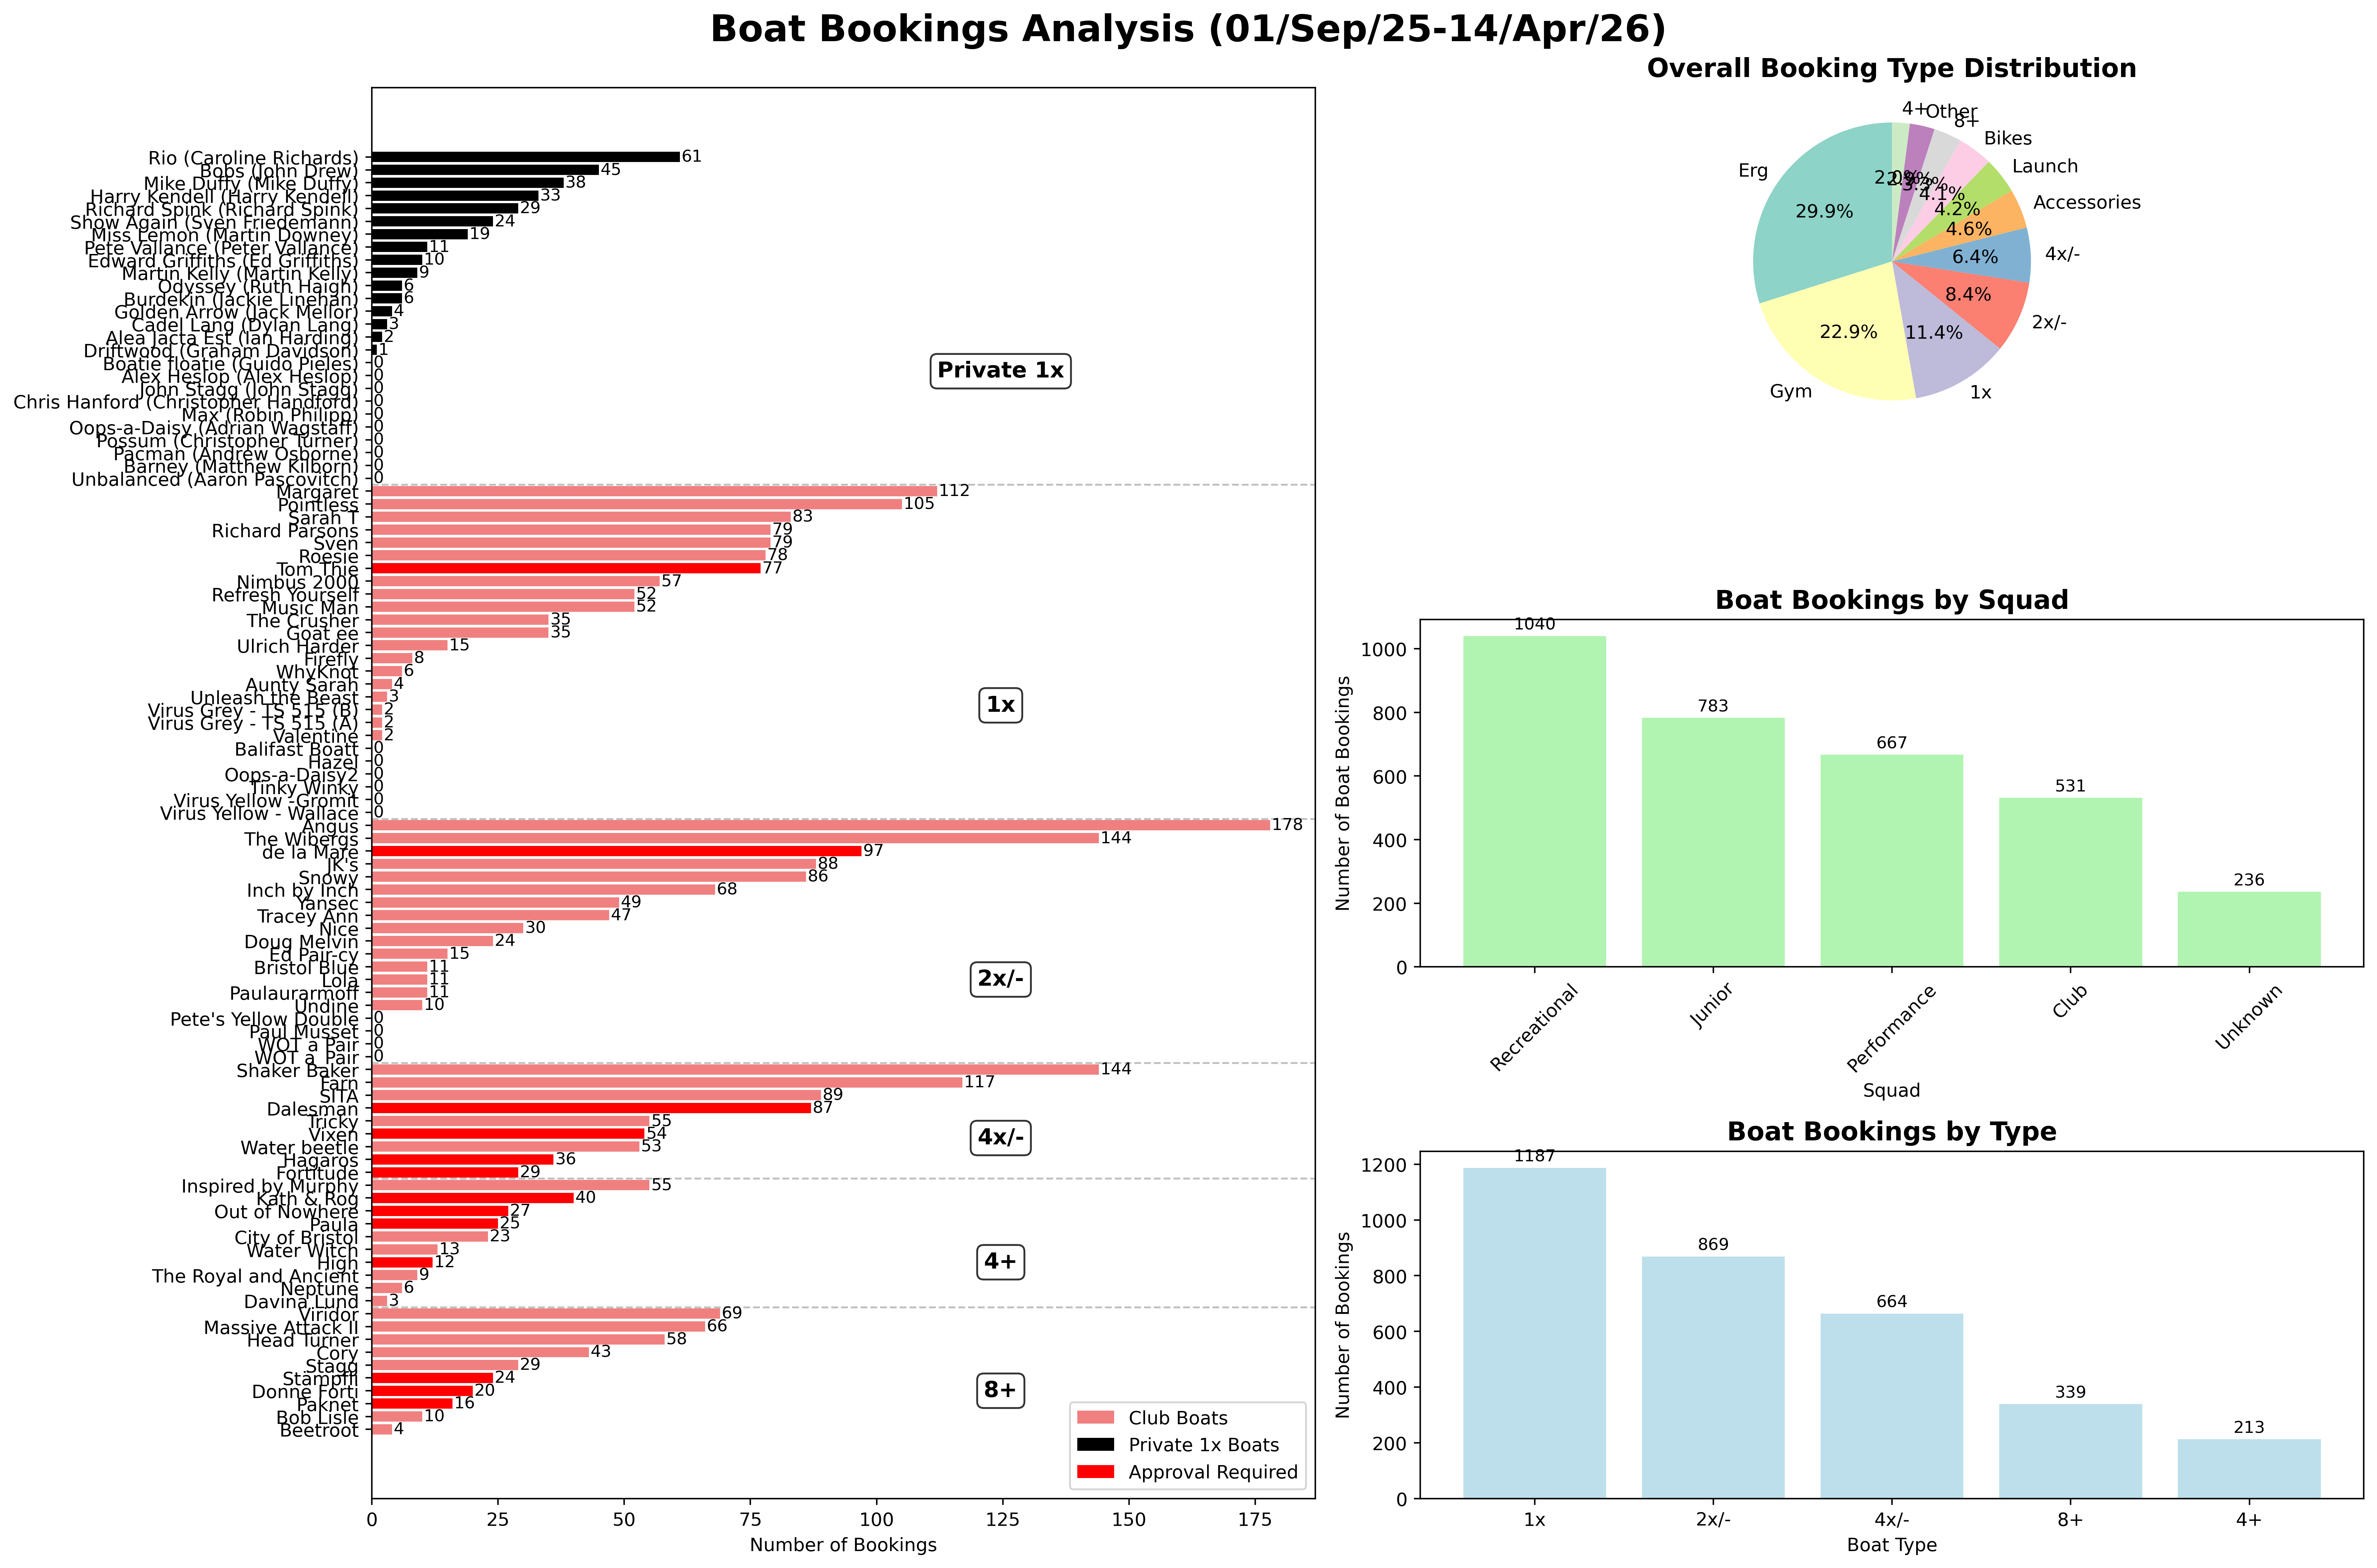

In [13]:
# Four-panel visualization: boats analysis
plt.figure(figsize=(18, 12),dpi=400)
first_date = bookings_df['start_date'].min().strftime('%d/%b/%y')
last_date = bookings_df['start_date'].max().strftime('%d/%b/%y')
plt.suptitle(f'Boat Bookings Analysis ({first_date}-{last_date})', fontsize=20, fontweight='bold')
# 1. Most Used Boats - including boats with zero bookings, grouped by type
plt.subplot(1, 2, 1)
boat_types = [
    "Private 1x",
    "1x",
    "2x/-",
    "4x/-",
    "4+",
    "8+",
]  # Added 'Private 1x' as separate type
boat_bookings = bookings_df[bookings_df['type'].isin(boat_types)]

# Get all boats of the specified types from boats_data, organized by type
boats_by_type = {boat_type: {} for boat_type in boat_types}
private_1x_names = set()
approval_required_names = set()
boat_type_map = {}  # Map boat name to boat type
boat_owner_map = {}  # Map boat name to owner name

for boat in boats_data:
    if boat["type"] in ['1x', '2x/-', '4x/-', '4+', '8+']:
        if boat["type"] == "1x" and boat["owner"] is not None:
            # This is a private 1x boat
            boats_by_type["Private 1x"][boat["name"]] = 0  # Initialize with 0 bookings
            boat_type_map[boat["name"]] = "Private 1x"
            private_1x_names.add(boat["name"])
            # Find owner name from user data
            owner_name = "Unknown"
            for user in data:
                if user.get('id') == boat["owner"]:
                    owner_name = user.get('name', 'Unknown')
                    break
            boat_owner_map[boat["name"]] = owner_name
        else:
            # This is a club boat (including club 1x boats)
            boats_by_type[boat["type"]][boat["name"]] = 0  # Initialize with 0 bookings
            boat_type_map[boat["name"]] = boat["type"]
        
        if boat.get("approval", False):  # Check if approval is required
            approval_required_names.add(boat["name"])

# Count actual bookings for each boat
boat_booking_counts = boat_bookings['equipment_name'].value_counts()
for boat_name, count in boat_booking_counts.items():
    boat_type = boat_type_map.get(boat_name)
    if boat_type and boat_name in boats_by_type[boat_type]:
        boats_by_type[boat_type][boat_name] = count

# Create ordered list grouped by type, with boats sorted by usage within each type
all_boats_ordered = []
all_boats_display = []  # Display names with owner info for private boats
all_bookings_ordered = []
group_positions = {}  # Track where each group starts for text labels

current_pos = 0
for boat_type in boat_types:
    # Sort boats within each type by booking count (descending)
    type_boats = pd.Series(boats_by_type[boat_type]).sort_values(ascending=False)
    if len(type_boats) > 0:
        group_positions[boat_type] = current_pos + len(type_boats) // 2  # Middle of the group
        for boat_name in type_boats.index:
            all_boats_ordered.append(boat_name)
            # Add owner name for private boats
            if boat_name in private_1x_names:
                owner_name = boat_owner_map.get(boat_name, "Unknown")
                display_name = f"{boat_name} ({owner_name})"
            else:
                display_name = boat_name
            all_boats_display.append(display_name)
        all_bookings_ordered.extend(type_boats.values.tolist())
        current_pos += len(type_boats)

# Create colors array - different colors for each boat type
colors = []
for boat_name in all_boats_ordered:
    boat_type = boat_type_map.get(boat_name)
    if boat_type == 'Private 1x':
        colors.append('black')  # Black for private 1x boats
    elif boat_name in approval_required_names:
        colors.append('red')  # Red for boats requiring approval
    else:
        colors.append('lightcoral')  # Light coral for all other boats

# sort all_boats_ordered and all_bookings_ordered by bookings descending
sorted_indices = sorted(
    range(len(all_bookings_ordered)),
    key=lambda i: all_bookings_ordered[i],
    reverse=True,
)

bars = plt.barh(range(len(all_boats_ordered)), all_bookings_ordered, color=colors)
plt.xlabel('Number of Bookings')
plt.yticks(range(len(all_boats_ordered)), all_boats_display)  # Use display names with owner info
plt.gca().invert_yaxis()  # To have the first boat type at the top

# Add value labels
for i, (bar, bookings) in enumerate(zip(bars, all_bookings_ordered)):
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(bookings)}', ha='left', va='center', fontsize=9)

# Add horizontal lines and text labels to separate boat types
y_positions = []
current_pos = 0
for boat_type in boat_types:
    type_count = len(boats_by_type[boat_type])
    if type_count > 0:
        current_pos += type_count
        if current_pos < len(all_boats_ordered):  # Don't add line after the last group
            y_positions.append(current_pos - 0.5)

for y_pos in y_positions:
    plt.axhline(y=y_pos, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Add text labels for each boat type group
ax = plt.gca()
max_bookings = max(all_bookings_ordered) if all_bookings_ordered else 1
text_x_position = max_bookings * 0.7  # Position text at 70% of max width

current_pos = 0
for boat_type in boat_types:
    type_count = len(boats_by_type[boat_type])
    if type_count > 0:
        # Calculate middle position of the group
        group_middle = current_pos + (type_count - 1) / 1.5
        plt.text(text_x_position, group_middle, boat_type, 
                ha='center', va='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        current_pos += type_count

# Legend with all boat categories
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='lightcoral', label='Club Boats'),
    plt.Rectangle((0,0),1,1, facecolor='black', label='Private 1x Boats'),
    plt.Rectangle((0,0),1,1, facecolor='red', label='Approval Required')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Right side - three charts stacked vertically
# 2. Overall Booking Pie Chart (all booking types)
plt.subplot(3, 2, 2)
type_counts = bookings_df['type'].value_counts()
colors_pie = plt.cm.Set3(range(len(type_counts)))
wedges, texts, autotexts = plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
                                   colors=colors_pie, startangle=90)
plt.title('Overall Booking Type Distribution', fontsize=14, fontweight='bold')

# 3. Boat Bookings by Squad
plt.subplot(3, 2, 4)
boat_squad_counts = boat_bookings['user_squad'].value_counts()
plt.bar(range(len(boat_squad_counts)), boat_squad_counts.values, color='lightgreen', alpha=0.7)
plt.title('Boat Bookings by Squad', fontsize=14, fontweight='bold')
plt.xlabel('Squad')
plt.ylabel('Number of Boat Bookings')
# Map squad counts to name using 'squad' mapping
labels = [squad.get(s, s) for s in boat_squad_counts.index]
plt.xticks(range(len(boat_squad_counts)), labels, rotation=45)

# Add value labels on bars
for i, count in enumerate(boat_squad_counts.values):
    plt.text(i, count + max(boat_squad_counts.values) * 0.01, str(count), 
             ha='center', va='bottom', fontsize=9)

# 4. Boat Bookings by Type - simplified colors
plt.subplot(3, 2, 6)
boat_type_counts = boat_bookings['type'].value_counts()

plt.bar(range(len(boat_type_counts)), boat_type_counts.values, color='lightblue', alpha=0.8)
plt.title('Boat Bookings by Type', fontsize=14, fontweight='bold')
plt.xlabel('Boat Type')
plt.ylabel('Number of Bookings')
plt.xticks(range(len(boat_type_counts)), boat_type_counts.index, rotation=0)

# Add value labels on bars
for i, count in enumerate(boat_type_counts.values):
    plt.text(i, count + max(boat_type_counts.values) * 0.01, str(count), 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('boat_bookings_analysis.jpeg', dpi=400)
plt.show()

In [14]:
# Filter for 1x boats with owners
private_1x_boats = []
for boat in boats_data:
    if boat["type"] == "1x" and boat["owner"] is not None:
        private_1x_boats.append(boat)

# Create DataFrame for 1x boats
boats_df = pd.DataFrame(private_1x_boats)

# Filter bookings for these private 1x boats
private_1x_bookings = bookings_df[
    (bookings_df["type"] == "1x")
    & (bookings_df["equipment_name"].isin(boats_df["name"]))
].copy()
boat_owner_details = []

for _, boat in boats_df.iterrows():
    owner_id = boat['owner']
    boat_name = boat['name']
    
    # Get bookings for this boat
    boat_bookings = private_1x_bookings[private_1x_bookings['equipment_name'] == boat_name]
    
    # Try to find owner name from user data (if user ID matches owner ID)
    owner_name = "Unknown"
    if 'df' in globals():  # Check if user dataframe exists
        # Convert user data to find matching ID
        user_match = None
        for user in data:  # Use original data list since it has numeric IDs
            if user.get('id') == owner_id:
                owner_name = user.get('name', 'Unknown')
                break
    
    boat_owner_details.append({
        'boat_name': boat_name,
        'owner_id': owner_id,
        'owner_name': owner_name,
        'total_bookings': len(boat_bookings),
        'available': boat['available'],
        'approval_required': boat['approval']
    })
total_bookings = sum(b["total_bookings"] for b in boat_owner_details)

# Sort by total bookings
boat_owner_details.sort(key=lambda x: x['total_bookings'], reverse=True)

print("🚣‍♀️ PRIVATE 1x BOAT DETAILS:")
print("-" * 50)
print(f"{'Rank':<4} {'Boat Name':<20} {'Owner':<20} {'Bookings':<8}")
print("-" * 70)

for i, boat in enumerate(boat_owner_details, 1):
    
    owner_display = boat['owner_name'] if boat['owner_name'] != "Unknown" else f"ID:{boat['owner_id']}"
    
    percentage = boat['total_bookings'] / total_bookings if total_bookings > 0 else 0
    print(
        f"{i:<4} {boat['boat_name']:<20} {owner_display:<20} {boat['total_bookings']:<4} ({percentage:>3.0%})"
    )

# Summary statistics
total_private_boats = len(boat_owner_details)
active_boats = len([b for b in boat_owner_details if b['total_bookings'] > 0])
unused_boats = total_private_boats - active_boats

print("\n📊 PRIVATE 1x BOAT SUMMARY:")
print("-" * 30)
print(f"Total private 1x boats: {total_private_boats}")
print(f"Boats with bookings:    {active_boats}")
print(f"Unused boats:           {unused_boats}")
print(f"Total bookings:           {total_bookings}")


🚣‍♀️ PRIVATE 1x BOAT DETAILS:
--------------------------------------------------
Rank Boat Name            Owner                Bookings
----------------------------------------------------------------------
1    Rio                  Caroline Richards    61   (20%)
2    Bobs                 John Drew            45   (15%)
3    Mike Duffy           Mike Duffy           38   (13%)
4    Harry Kendell        Harry Kendell        33   (11%)
5    Richard Spink        Richard Spink        29   (10%)
6    Show Again           Sven Friedemann      24   ( 8%)
7    Miss Lemon           Martin Downey        19   ( 6%)
8    Pete Vallance        Peter Vallance       11   ( 4%)
9    Edward Griffiths     Ed Griffiths         10   ( 3%)
10   Martin Kelly         Martin Kelly         9    ( 3%)
11   Burdekin             Jackie Linehan       6    ( 2%)
12   Odyssey              Ruth Haigh           6    ( 2%)
13   Golden Arrow         Jack Mellor          4    ( 1%)
14   Cadel Lang           Dylan Lang  

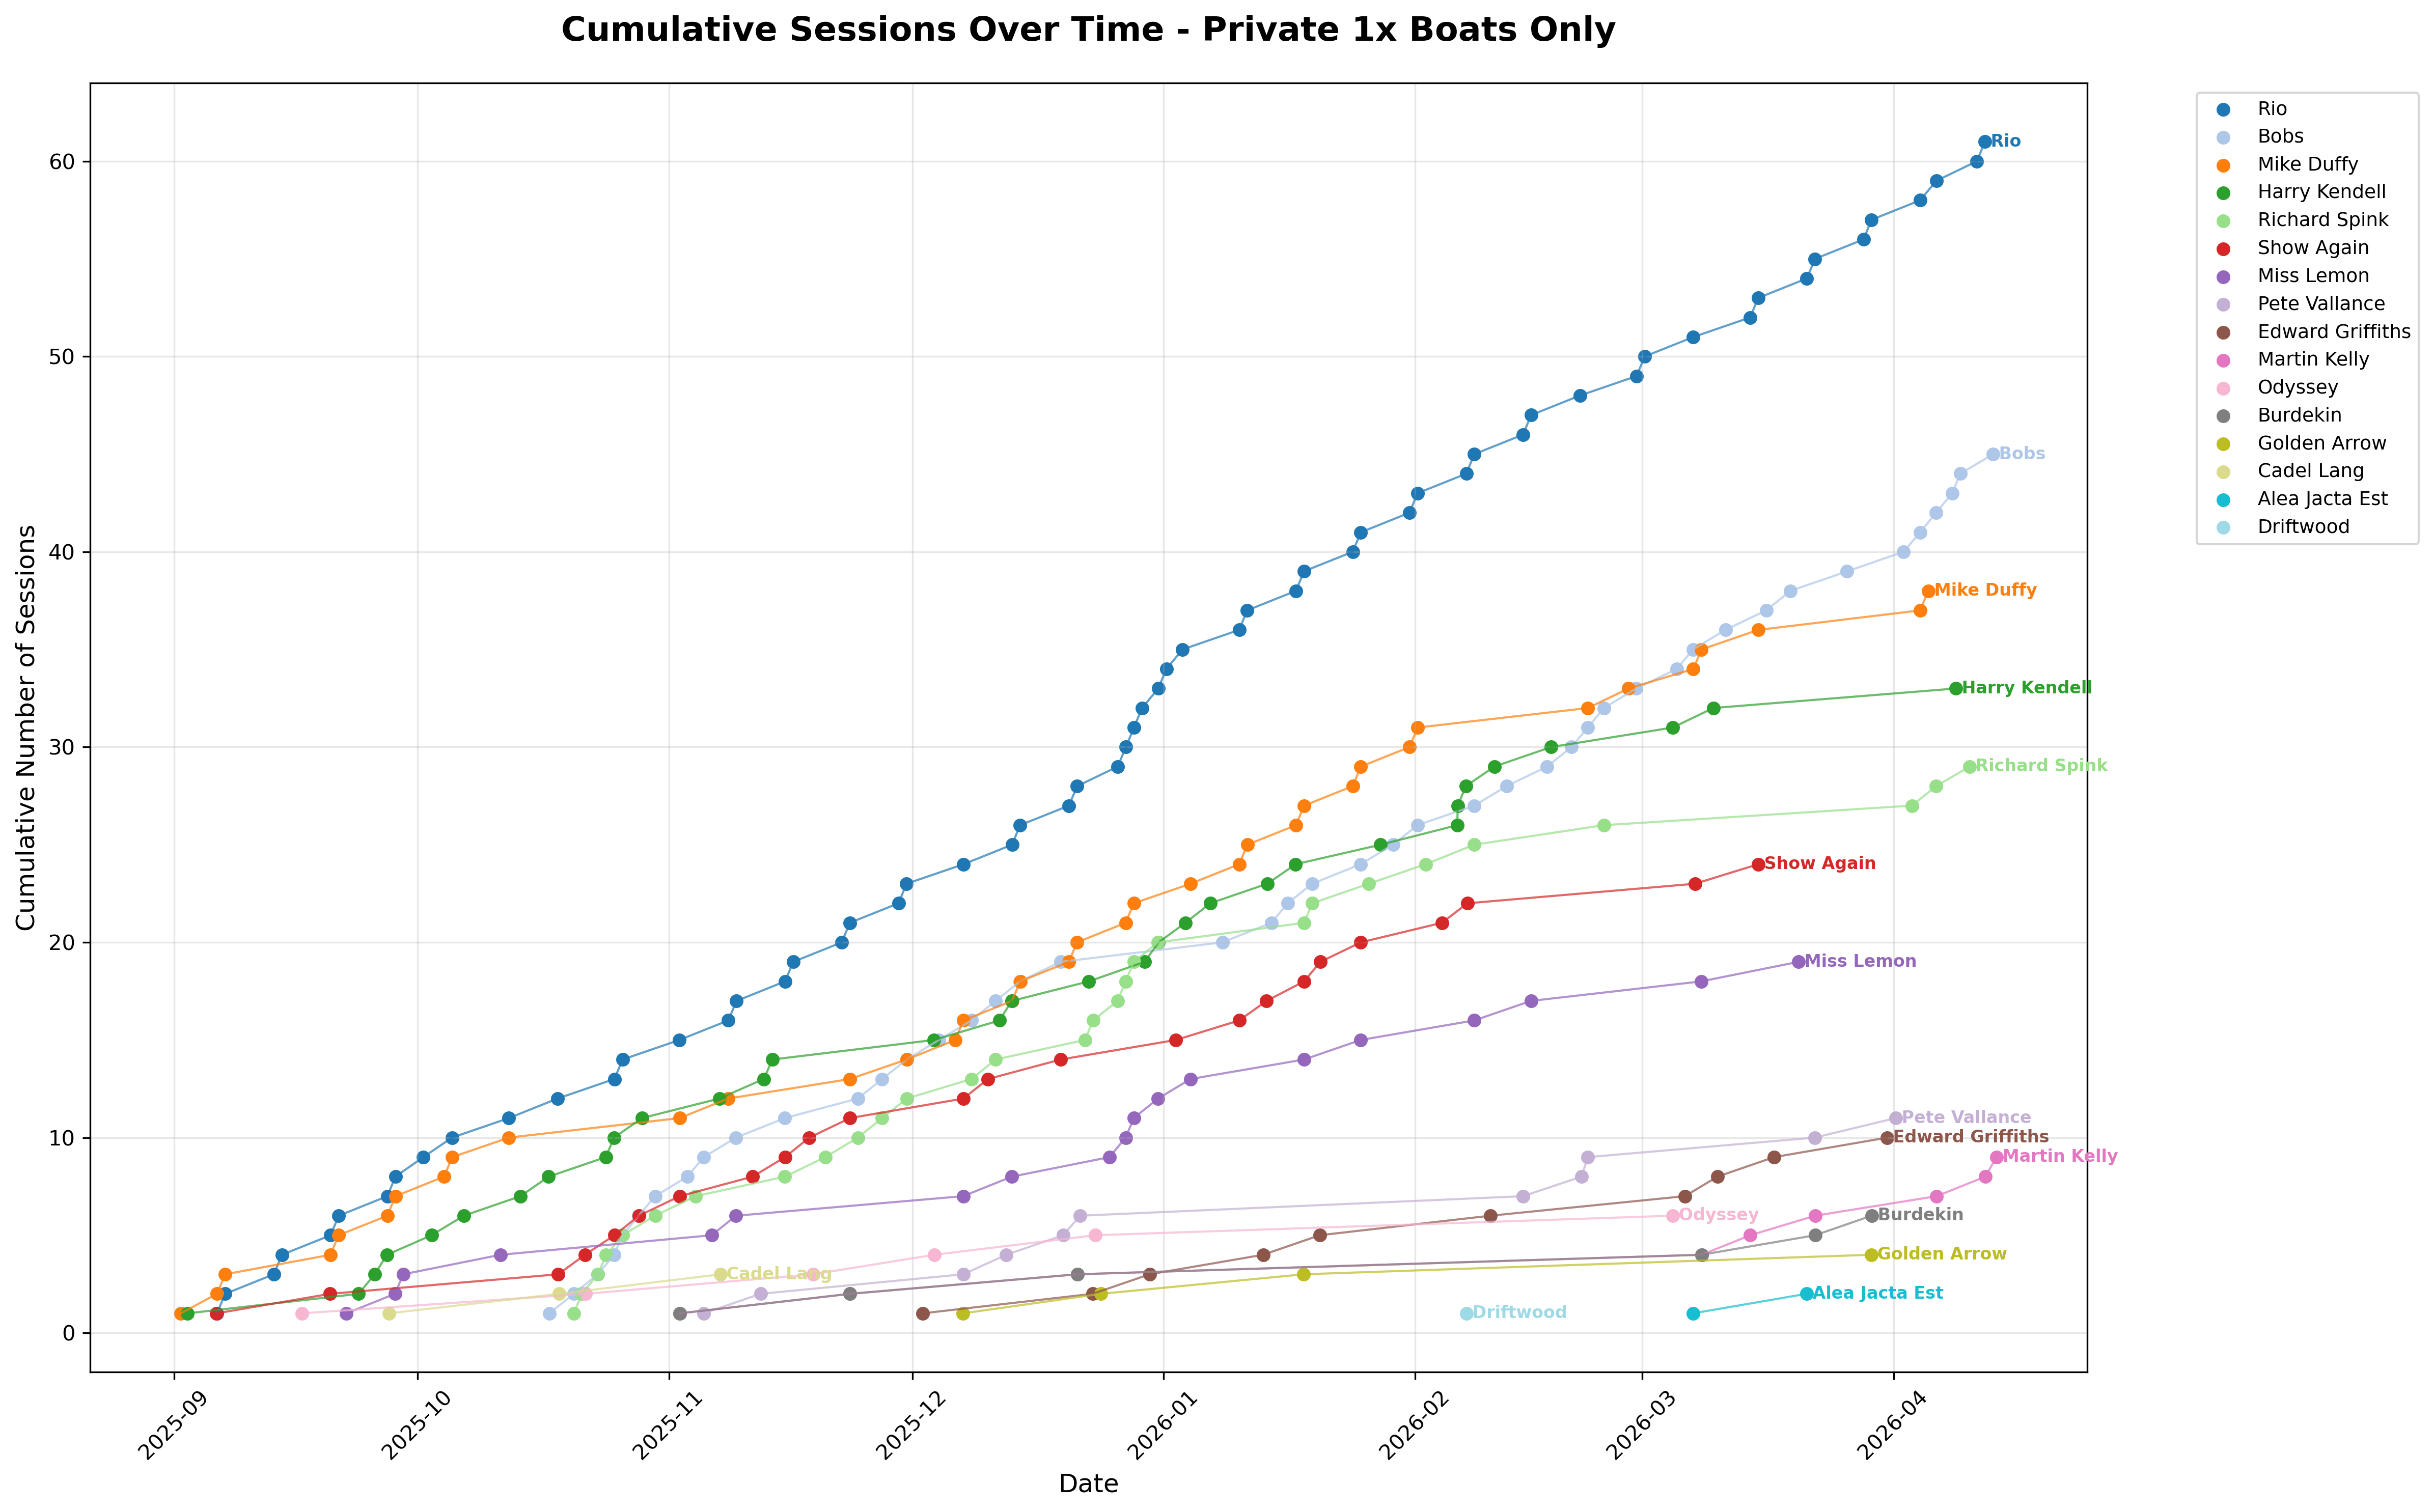

In [15]:
# Create accumulation plot for boat sessions over timeimport matplotlib.cm as cm
import numpy as np
import matplotlib.cm as cm
plt.figure(figsize=(16, 10), dpi=300)

# Filter for boat types we're interested in
boat_types = ['1x', '2x/-', '4x/-', '4+', '8+']
boat_bookings = bookings_df[bookings_df['type'].isin(boat_types)].copy()

# Sort by date to ensure proper accumulation
boat_bookings = boat_bookings.sort_values('start_date')

# Get only private boats (1x boats with owners)
private_boat_names = []
for boat in boats_data:
    if boat["type"] == "1x" and boat["owner"] is not None:
        private_boat_names.append(boat["name"])

# Filter bookings for private boats only
private_boat_bookings = boat_bookings[boat_bookings['equipment_name'].isin(private_boat_names)]

# Get usage counts for private boats and sort by usage
private_boats_usage = private_boat_bookings['equipment_name'].value_counts()
top_boat_names = private_boats_usage.index.tolist()

# Use the private boat bookings for the plot
top_boat_bookings = private_boat_bookings

# Create accumulation data for each boat
boat_accumulation = {}
for boat_name in top_boat_names:
    boat_data = top_boat_bookings[top_boat_bookings['equipment_name'] == boat_name]
    # Create cumulative count
    boat_data = boat_data.sort_values('start_date')
    boat_data['cumulative_count'] = range(1, len(boat_data) + 1)
    boat_accumulation[boat_name] = boat_data[['start_date', 'cumulative_count']]

# Create different colors for each boat
colors = cm.tab20(np.linspace(0, 1, len(top_boat_names)))

# Plot accumulation scatter plots
for i, boat_name in enumerate(top_boat_names):
    if boat_name in boat_accumulation:
        data = boat_accumulation[boat_name]
        color = colors[i]
        
        plt.scatter(data['start_date'], data['cumulative_count'], 
                   color=color, s=30, label=boat_name)
        plt.plot(data['start_date'], data['cumulative_count'], 
                 color=color, alpha=0.7, linewidth=1)
        
        # Add boat name at the end (highest point)
        if len(data) > 0:
            final_date = data['start_date'].iloc[-1]
            final_count = data['cumulative_count'].iloc[-1]
            plt.text(final_date, final_count, f' {boat_name}', 
                    fontsize=8, color=color, 
                    verticalalignment='center', fontweight='bold')

plt.title('Cumulative Sessions Over Time - Private 1x Boats Only', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Number of Sessions', fontsize=12)
plt.grid(True, alpha=0.3)

# Format x-axis to show dates nicely
plt.xticks(rotation=45)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Tight layout to prevent legend cutoff
plt.tight_layout()
plt.show()